
# Tier 1 — National Screening: CCS Potential Across Indonesian Basins

**Status: PROTOTYPE.** This notebook automatically uses **real emitter
data** (`data/processed/basins_processed.csv`, `data/raw/indonesia_emitters_real.csv`)
if present, and falls back to **illustrative sample data** otherwise — the
active data source is always printed explicitly in Section 1.

This notebook replicates the *spirit* of two studies:

- **de Jonge-Anderson et al. (2025)** — *Malay Basin*, IJGGC 143 — technical
  workflow (subsurface cut-offs, CO2 thermophysics, clustering, Monte Carlo).
- **Nooraiepour et al. (2025)** — *Poland*, IJGGC 148 — strategic framework
  for an emerging CCS region: **resource-reserve pyramid** & **Storage
  Readiness Level (SRL)**.

> ⚠️ Capacity figures and basin geometry are **illustrative** unless the
> active-data-source message in Section 1 says otherwise. See
> `docs/methodology.md` for full limitations.


## 0. Setup

In [3]:

import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_p = Path.cwd()
while not (_p / "config.yaml").exists() and _p != _p.parent:
    _p = _p.parent
REPO_ROOT = _p
sys.path.insert(0, str(REPO_ROOT / "src"))

from load_config import load_config
from emission_source_proximity import nearest_emitter_distance
from montecarlo_capacity import monte_carlo_capacity, summarize_capacity, NormalParam

cfg = load_config(REPO_ROOT / "config.yaml")
pd.set_option("display.max_colwidth", 60)
print("Repo root:", REPO_ROOT)
print("Target SRL Tier 1:", cfg["storage_readiness"]["tier1_target_srl"])


Repo root: c:\Users\Arsy Nuur\ccs-screening
Target SRL Tier 1: 1


## 1. Load basin & emission source data

Priority: real data (`config.yaml` §`paths.real`) first, illustrative
sample data (`config.yaml` §`paths.sample`) as fallback — generated
automatically via `fetch_open_data.py` if not already present.


In [5]:

real_basins_path = REPO_ROOT / cfg["paths"]["real"]["basins_processed"]
real_emitters_path = REPO_ROOT / cfg["paths"]["real"]["emitters"]
sample_basins_path = REPO_ROOT / cfg["paths"]["sample"]["basins"]
sample_emitters_path = REPO_ROOT / cfg["paths"]["sample"]["emitters"]

# Make sure the illustrative fallback files exist (safe to call repeatedly)
if not sample_basins_path.exists() or not sample_emitters_path.exists():
    subprocess.run([sys.executable, str(REPO_ROOT / "src" / "fetch_open_data.py"), "--mode", "sample"], check=True)

print("=== ACTIVE DATA SOURCE ===")
if real_basins_path.exists():
    basins_path, basins_source = real_basins_path, "REAL"
else:
    basins_path, basins_source = sample_basins_path, "ILLUSTRATIVE (sample)"
print(f"Basins  : {basins_source} -> {basins_path.name}")

if real_emitters_path.exists():
    emitters_path, emitters_source = real_emitters_path, "REAL"
else:
    emitters_path, emitters_source = sample_emitters_path, "ILLUSTRATIVE (sample)"
print(f"Emitters: {emitters_source} -> {emitters_path.name}")
print("==========================\n")

basins = pd.read_csv(basins_path)
emitters = pd.read_csv(emitters_path)

# Align column names in case real data uses different conventions
# (e.g. GEM-style "Latitude"/"Longitude" instead of "lat"/"lon").
emitters = emitters.rename(columns={
    "Latitude": "lat", "Longitude": "lon", "annual_co2_mtpa": "capacity_mtpa_co2_est",
})
if "name" not in emitters.columns:
    emitters["name"] = emitters.get("Plant name", "unnamed_emitter")
if "sector" not in emitters.columns:
    emitters["sector"] = "unknown"

print(f"{len(basins)} basins, {len(emitters)} emitter points loaded.")
basins[["basin", "region", "basin_type", "ccs_policy_priority", "srl_placeholder"]]


=== ACTIVE DATA SOURCE ===
Basins  : ILLUSTRATIVE (sample) -> sample_basins_indonesia.csv
Emitters: REAL -> indonesia_emitters_real.csv

8 basins, 1565 emitter points loaded.


,basin,region,basin_type,ccs_policy_priority,srl_placeholder
0,Sunda-Asri Basin,Offshore West Java,"Rift, saline aquifer + depleted field",True,1
1,South Sumatra Basin,Onshore/nearshore South Sumatra,"Foreland/back-arc, depleted field",True,1
2,North Sumatra Basin,Onshore/offshore Aceh-North Sumatra,"Rift/foreland, depleted field",False,1
3,Northwest Java Basin,Onshore/offshore West Java,"Rift, saline aquifer",False,1
4,East Java Basin,Onshore/offshore East Java,"Foreland, depleted field",False,1
5,Kutai Basin,Offshore East Kalimantan,"Deltaic rift, saline aquifer",False,1
6,Bintuni Basin,Onshore/offshore West Papua,"Foreland, depleted field",True,1
7,"Malay Basin (Natuna, Indonesian side)",Offshore Riau Islands,"Rift, saline aquifer + depleted field",False,1


## 2. Storage Readiness Level (SRL) framework per basin

| SRL | Description |
|---|---|
| 1 | First-pass, basin/country-scale assessment using existing geological data |
| 2 | Sites with theoretical capacity mapped systematically |
| 3 | Detailed site-specific screening study + preliminary project concept |

All example basins here stay at **SRL 1** — honest, given this only uses
basin-level public data, not well data.


In [6]:

srl_labels = {1: "SRL 1 - basin-scale, public data", 2: "SRL 2 - systematically mapped capacity", 3: "SRL 3 - site-specific detailed screening"}
basins["srl_label"] = basins["srl_placeholder"].map(srl_labels)
basins[["basin", "srl_placeholder", "srl_label", "ccs_policy_priority"]]


,basin,srl_placeholder,srl_label,ccs_policy_priority
0,Sunda-Asri Basin,1,"SRL 1 - basin-scale, public data",True
1,South Sumatra Basin,1,"SRL 1 - basin-scale, public data",True
2,North Sumatra Basin,1,"SRL 1 - basin-scale, public data",False
3,Northwest Java Basin,1,"SRL 1 - basin-scale, public data",False
4,East Java Basin,1,"SRL 1 - basin-scale, public data",False
5,Kutai Basin,1,"SRL 1 - basin-scale, public data",False
6,Bintuni Basin,1,"SRL 1 - basin-scale, public data",True
7,"Malay Basin (Natuna, Indonesian side)",1,"SRL 1 - basin-scale, public data",False


## 3. Proximity to CO2 emission sources

Great-circle distance from each basin centroid to the nearest emitter
(analogous to Fig. 7 in the Poland paper).


In [7]:

capacity_col = "capacity_mtpa_co2_est" if "capacity_mtpa_co2_est" in emitters.columns else None

basins_with_proximity = nearest_emitter_distance(
    basins, emitters,
    basin_lat_col="lat", basin_lon_col="lon",
    emitter_lat_col="lat", emitter_lon_col="lon",
    emitter_capacity_col=capacity_col,
)
cols = ["basin", "nearest_emitter_name", "nearest_emitter_km"]
if "nearest_emitter_capacity" in basins_with_proximity.columns:
    cols.append("nearest_emitter_capacity")
basins_with_proximity[cols].sort_values("nearest_emitter_km")


,basin,nearest_emitter_name,nearest_emitter_km,nearest_emitter_capacity
4,East Java Basin,unnamed_emitter,15.406532,2.500000
1,South Sumatra Basin,unnamed_emitter,20.222279,0.620000
3,Northwest Java Basin,unnamed_emitter,31.526236,1.958919
5,Kutai Basin,unnamed_emitter,39.555140,1.800000
0,Sunda-Asri Basin,unnamed_emitter,47.740675,0.000000
2,North Sumatra Basin,unnamed_emitter,89.678936,0.000000
6,Bintuni Basin,unnamed_emitter,156.105089,0.900000
7,"Malay Basin (Natuna, Indonesian side)",unnamed_emitter,351.013311,0.586995


## 4. Resource-reserve pyramid per basin (Monte Carlo)

Distribution parameters (Swirr, efficiency factor) come from `config.yaml`;
area/thickness/NTG/porosity/density use illustrative ranges per basin
(labelled explicitly — see `docs/methodology.md`).


In [8]:

ce = cfg["capacity_equation"]
rng = np.random.default_rng(42)
illustrative_results = []

for _, row in basins.iterrows():
    area_km2 = rng.uniform(5_000, 70_000)  # order-of-magnitude realistic for a sedimentary basin
    mc = monte_carlo_capacity(
        area_km2=area_km2,
        thickness_m=NormalParam(mean=rng.uniform(150, 500), std=100, lower_bound=0),
        ntg_fraction=NormalParam(mean=rng.uniform(0.15, 0.4), std=0.1, lower_bound=0, upper_bound=1),
        porosity_fraction=NormalParam(mean=rng.uniform(0.15, 0.28), std=0.04, lower_bound=0, upper_bound=1),
        swirr_fraction=NormalParam(mean=ce["swirr_mean"], std=ce["swirr_std"], lower_bound=0, upper_bound=1),
        efficiency_fraction=NormalParam(
            mean=ce["efficiency_factor_percent_mean"] / 100,
            std=ce["efficiency_factor_percent_std"] / 100,
            lower_bound=0, upper_bound=1,
        ),
        co2_density_kgm3=NormalParam(mean=rng.uniform(300, 450), std=40, lower_bound=0),
        n_iterations=ce["monte_carlo_iterations"],
        random_seed=int(rng.integers(0, 10_000)),
    )
    stats = summarize_capacity(mc)
    stats["basin"] = row["basin"]
    stats["illustrative_area_km2"] = area_km2
    illustrative_results.append(stats)

illustrative_df = pd.DataFrame(illustrative_results).set_index("basin")
illustrative_df = illustrative_df[["illustrative_area_km2", "P10_Gt", "P50_Gt", "P90_Gt", "mean_Gt", "std_Gt"]]
illustrative_df.round(2)


,illustrative_area_km2,P10_Gt,P50_Gt,P90_Gt,mean_Gt,std_Gt
basin,,,,,,
Sunda-Asri Basin,55307.14,11.02,5.70,2.31,6.39,3.69
South Sumatra Basin,54474.08,8.56,3.68,0.83,4.37,3.30
North Sumatra Basin,65239.72,15.01,8.08,3.85,8.99,4.67
Northwest Java Basin,9148.12,2.67,1.40,0.62,1.54,0.84
East Java Basin,68095.37,16.73,9.10,4.26,9.92,5.22
Kutai Basin,15028.82,4.87,2.56,1.15,2.79,1.47
Bintuni Basin,29079.88,3.00,1.33,0.41,1.55,1.09
"Malay Basin (Natuna, Indonesian side)",48537.91,10.50,5.69,2.69,6.32,3.49


## 5. Summary visualization (style of Table 2 / Fig. 7, Poland paper)

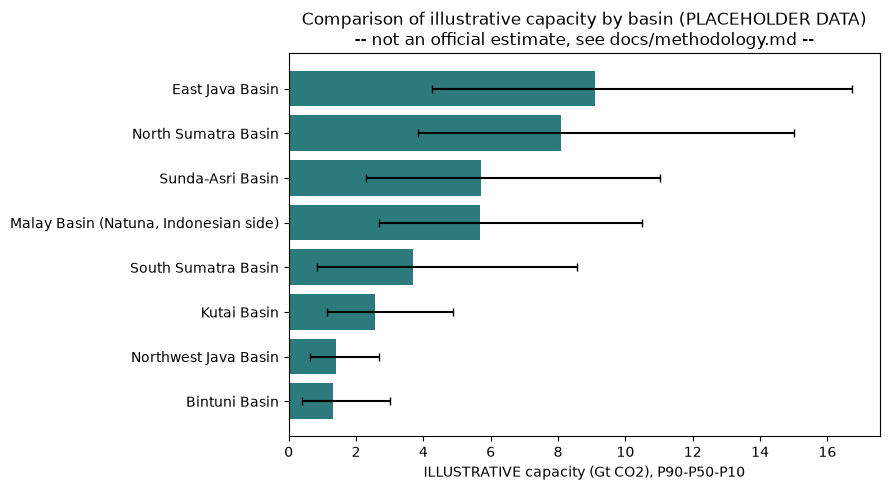

In [9]:

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = illustrative_df.sort_values("P50_Gt", ascending=True)
ax.barh(plot_df.index, plot_df["P50_Gt"], color="#2c7a7b")
ax.errorbar(
    plot_df["P50_Gt"], plot_df.index,
    xerr=[plot_df["P50_Gt"] - plot_df["P90_Gt"], plot_df["P10_Gt"] - plot_df["P50_Gt"]],
    fmt="none", ecolor="black", capsize=3,
)
ax.set_xlabel("ILLUSTRATIVE capacity (Gt CO2), P90-P50-P10")
ax.set_title("Comparison of illustrative capacity by basin (PLACEHOLDER DATA)\n"
              "-- not an official estimate, see docs/methodology.md --")
plt.tight_layout()

figures_dir = REPO_ROOT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "tier1_illustrative_capacity_comparison.png", dpi=150)
plt.show()


In [10]:

import folium

m = folium.Map(location=[-2.5, 113], zoom_start=5, tiles="cartodbpositron")

for _, row in basins.iterrows():
    color = "crimson" if row["ccs_policy_priority"] else "steelblue"
    note_text = row["note"] if "note" in basins.columns else "No description available"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=9, color=color, fill=True, fill_opacity=0.85,
        popup=f"<b>{row['basin']}</b><br>{row['region']}<br>{note_text}",
    ).add_to(m)

for _, row in emitters.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=3, color="gray", fill=True, fill_opacity=0.5,
        popup=f"{row['name']} ({row['sector']})",
    ).add_to(m)

emitter_label = f"Emitter source: {emitters_source}"
legend_html = (
    '<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999; '
    'background: white; padding: 10px; border: 1px solid #999; font-size: 13px;">'
    '<b>Legend</b><br>'
    '<span style="color:crimson;">&#9679;</span> Priority CCS basin (official policy)<br>'
    '<span style="color:steelblue;">&#9679;</span> Other basin<br>'
    f'<span style="color:gray;">&#9679;</span> {emitter_label}'
    '</div>'
)
m.get_root().html.add_child(folium.Element(legend_html))

figures_dir = REPO_ROOT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
m.save(str(figures_dir / "tier1_indonesia_basins_map.html"))
print(f"Interactive map saved to {figures_dir / 'tier1_indonesia_basins_map.html'}")
m


Interactive map saved to c:\Users\Arsy Nuur\ccs-screening\figures\tier1_indonesia_basins_map.html


## 6. Summary & next steps

**Demonstrated in this notebook:**
1. SRL framework per basin (Poland paper style, §3.2)
2. Basin <-> emitter proximity analysis (Poland paper style, Fig. 7)
3. Resource-reserve pyramid workflow with Monte Carlo (Poland Eq. 1-2 &
   Malay Basin Eq. 2), using illustrative geometry unless real data is present

**Honest limitations (still open):**
- Basin geometry is illustrative (centroids, not digitized polygons) unless
  real processed data is supplied.
- Emitter data falls back to synthetic points unless a real ingested
  emitter file is present.
- Local Indonesian geothermal gradient & porosity-depth trends still use
  generic global proxies in `config.yaml`.

**Next:** `01_tier2_sunda_asri_workflow.ipynb` — full depth/temperature/
pressure grid workflow with real CO2 thermophysics (CoolProp), triple
cut-off (porosity + CO2 density + fault distance), DBSCAN clustering, and
Monte Carlo capacity, specific to the Sunda-Asri Basin.
